In [1]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [2]:
Ns_to_sweep = np.arange(3, 41)
f_rf_r = 3e6
f_rf_a = 125e3
P = 100e-3
w0 = 1e-6
ueq_dict = {N:ion_spacing(N, f_rf_a * 2 * pi)[0] for N in Ns_to_sweep}
N_checking = [5,6]
tweezer_combos_full_radial_middle_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_checking,
    f_rf_r,
    ueq_dict,
    P,
    w0,
    max_tweezed=2,
    qubit_lambda = 729e-9
)

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec,Mode3_freq,Mode3_eigvec,Mode4_freq,Mode4_eigvec,Mode5_freq,Mode5_eigvec
0,5,"(2,)",0.10,"[18849555.92153876, 18849555.92153876, 18956052.28782825, 18849555.92153876, 18849555.92153876]",3.009434e+06,"[0.005706734434342842, 0.01474548558075587, 0.05120206357686523, 0.01474548558080322, 0.0057067344342820354]",2.997395e+06,"[-0.03580346677500765, -0.01688794697747385, -3.5094257440385783e-13, 0.01688794697794417, 0.03580346677718937]",2.996913e+06,"[-0.03644592096603259, -0.011437557202128872, 0.014711888570268254, -0.01143755720081595, -0.03644592096412343]",2.989131e+06,"[0.016911274500595076, -0.03585292253178419, -1.0507154097562671e-12, 0.03585292253573528, -0.016911274501853556]",2.988094e+06,"[0.01438553750077954, -0.03495401073012265, 0.016925857620030283, -0.03495401072622326, 0.014385537498687399]",NaN,NaN
1,6,"(2, 3)",0.05,"[18849555.92153876, 18849555.92153876, 18902879.10316965, 18902879.10316965, 18849555.92153876, 18849555.92153876]",3.004714e+06,"[0.010050080553266854, 0.017289105277636104, 0.03410801250839805, 0.03410801250839878, 0.017289105277686463, 0.010050080553185901]",2.997815e+06,"[-0.03151007222590517, -0.020615517792662633, -0.012206022298194693, 0.012206022298097915, 0.02061551779266036, 0.03151007222639646]",2.995781e+06,"[0.036064092521163084, 0.007597312039395769, -0.01447747101816958, -0.014477471018695101, 0.0075973120385819295, 0.0360640925212883]",2.991544e+06,"[0.02262324713245673, -0.018902042927203138, -0.026477483077141498, 0.026477483076490744, 0.018902042928065896, -0.02262324713201081]",2.985386e+06,"[0.012906938515950392, -0.03485148510213628, 0.01386287820489721, 0.01386287820635716, -0.03485148510278269, 0.012906938515648671]",2.983119e+06,"[0.007972291634869975, -0.02809271773037208, 0.026866937400408027, -0.02686693740005942, 0.028092717729181656, -0.007972291634209212]"


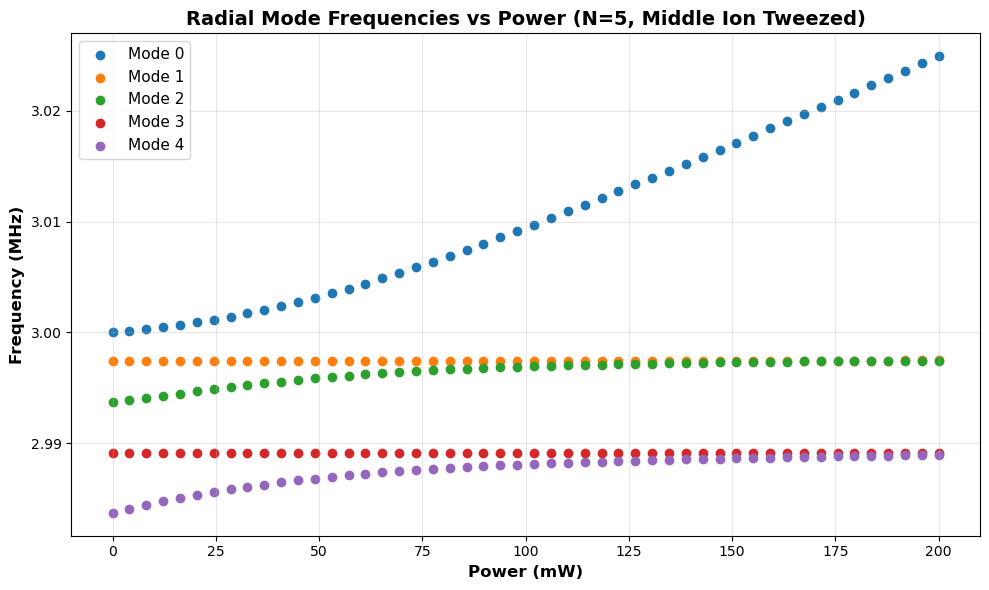

In [3]:
# Sweep over power for N=5 and plot all mode frequencies
N = 5
P_sweep = np.linspace(0, 200, 50) * 1e-3  # 0 to 500 mW in 50 steps

# Get mode frequencies for each power
all_modes_N5 = []
for P in P_sweep:
    result_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        [N],
        f_rf_r,
        ueq_dict,
        P,
        w0,
        max_tweezed=1,
        qubit_lambda=729e-9
    )
    all_modes_N5.append(result_df)

# Extract mode frequencies
mode_freqs_N5 = {i: [] for i in range(N)}
for result in all_modes_N5:
    for mode_idx in range(N):
        freq = result[f"Mode{mode_idx}_freq"].values[0]
        mode_freqs_N5[mode_idx].append(freq if not np.isnan(freq) else None)

# Plot
plt.figure(figsize=(10, 6))
for mode_idx in range(N):
    valid_freqs = [f for f in mode_freqs_N5[mode_idx] if f is not None]
    valid_powers = [P_sweep[i] * 1e3 for i, f in enumerate(mode_freqs_N5[mode_idx]) if f is not None]
    plt.scatter(valid_powers, np.array(valid_freqs) / 1e6, marker='o', label=f'Mode {mode_idx}')

plt.xlabel('Power (mW)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (MHz)', fontsize=12, fontweight='bold')
plt.title(f'Radial Mode Frequencies vs Power (N={N}, Middle Ion Tweezed)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

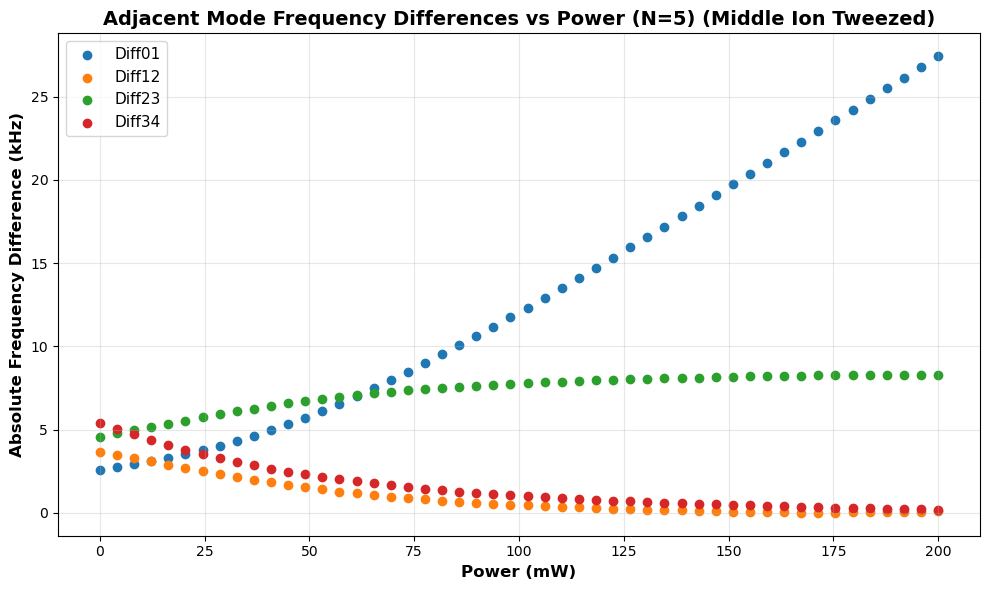

In [4]:
def plot_mode_differences(mode_freqs, P_sweep, N, title_suffix=""):
    # Compute absolute differences between adjacent modes
    diff_dict = {f"Diff{i}{i+1}": [] for i in range(N - 1)}
    for idx in range(len(P_sweep)):
        for i in range(N - 1):
            f1 = mode_freqs[i][idx]
            f2 = mode_freqs[i + 1][idx]
            if f1 is None or f2 is None:
                diff_dict[f"Diff{i}{i+1}"].append(None)
            else:
                diff_dict[f"Diff{i}{i+1}"].append(abs(f2 - f1))

    plt.figure(figsize=(10, 6))
    for i in range(N - 1):
        key = f"Diff{i}{i+1}"
        valid_diffs = [d for d in diff_dict[key] if d is not None]
        valid_powers = [P_sweep[j] * 1e3 for j, d in enumerate(diff_dict[key]) if d is not None]
        plt.scatter(valid_powers, np.array(valid_diffs) / 1e3, marker='o', label=key)

    plt.xlabel('Power (mW)', fontsize=12, fontweight='bold')
    plt.ylabel('Absolute Frequency Difference (kHz)', fontsize=12, fontweight='bold')
    title = f'Adjacent Mode Frequency Differences vs Power (N={N})'
    if title_suffix:
        title = f"{title} {title_suffix}"
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot differences for N=5
plot_mode_differences(mode_freqs_N5, P_sweep, N, title_suffix='(Middle Ion Tweezed)')

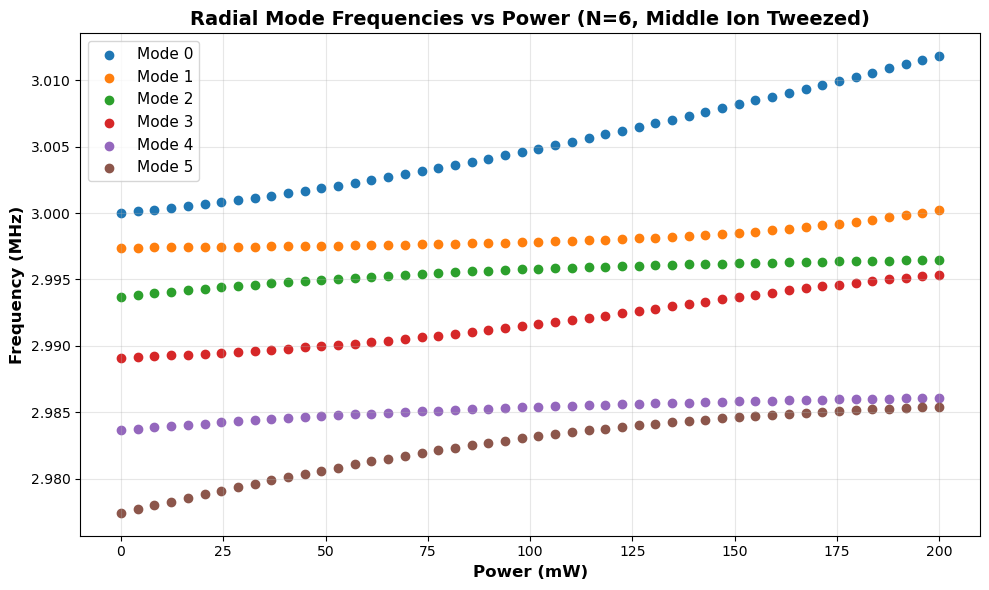

In [5]:
# Sweep over power for N=5 and plot all mode frequencies
N = 6
P_sweep = np.linspace(0, 200, 50) * 1e-3  # 0 to 500 mW in 50 steps

# Get mode frequencies for each power
all_modes_N6 = []
for P in P_sweep:
    result_df = tweezer_combos_full_radial_middle_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        [N],
        f_rf_r,
        ueq_dict,
        P,
        w0,
        max_tweezed=2,
        qubit_lambda=729e-9
    )
    all_modes_N6.append(result_df)

# Extract mode frequencies
mode_freqs_N6 = {i: [] for i in range(N)}
for result in all_modes_N6:
    for mode_idx in range(N):
        freq = result[f"Mode{mode_idx}_freq"].values[0]
        mode_freqs_N6[mode_idx].append(freq if not np.isnan(freq) else None)

# Plot
plt.figure(figsize=(10, 6))
for mode_idx in range(N):
    valid_freqs = [f for f in mode_freqs_N6[mode_idx] if f is not None]
    valid_powers = [P_sweep[i] * 1e3 for i, f in enumerate(mode_freqs_N6[mode_idx]) if f is not None]
    plt.scatter(valid_powers, np.array(valid_freqs) / 1e6, marker = 'o', label=f'Mode {mode_idx}')

plt.xlabel('Power (mW)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (MHz)', fontsize=12, fontweight='bold')
plt.title(f'Radial Mode Frequencies vs Power (N={N}, Middle Ion Tweezed)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

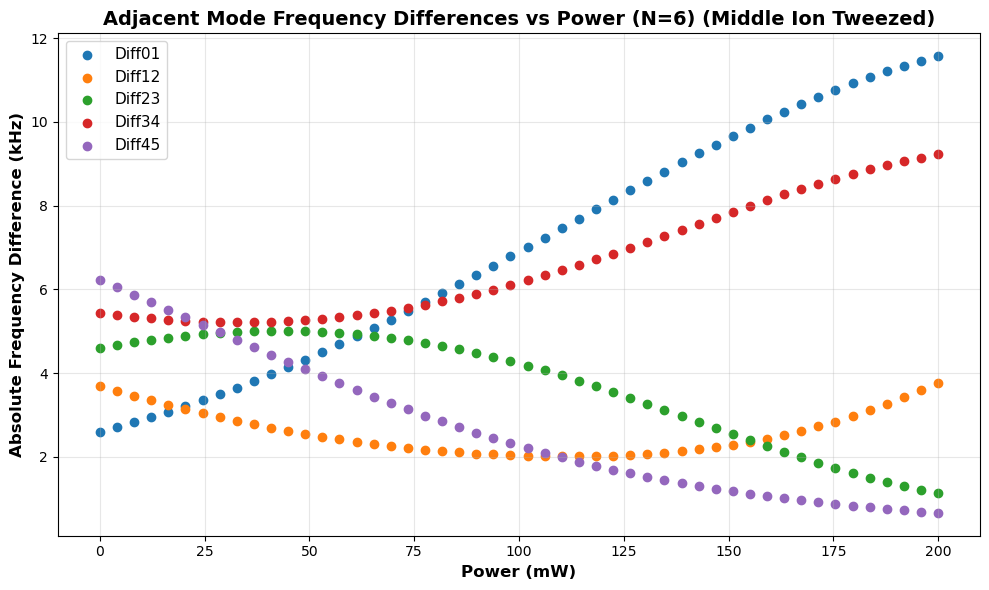

In [6]:
# Plot differences for N=6
plot_mode_differences(mode_freqs_N6, P_sweep, N, title_suffix='(Middle Ion Tweezed)')

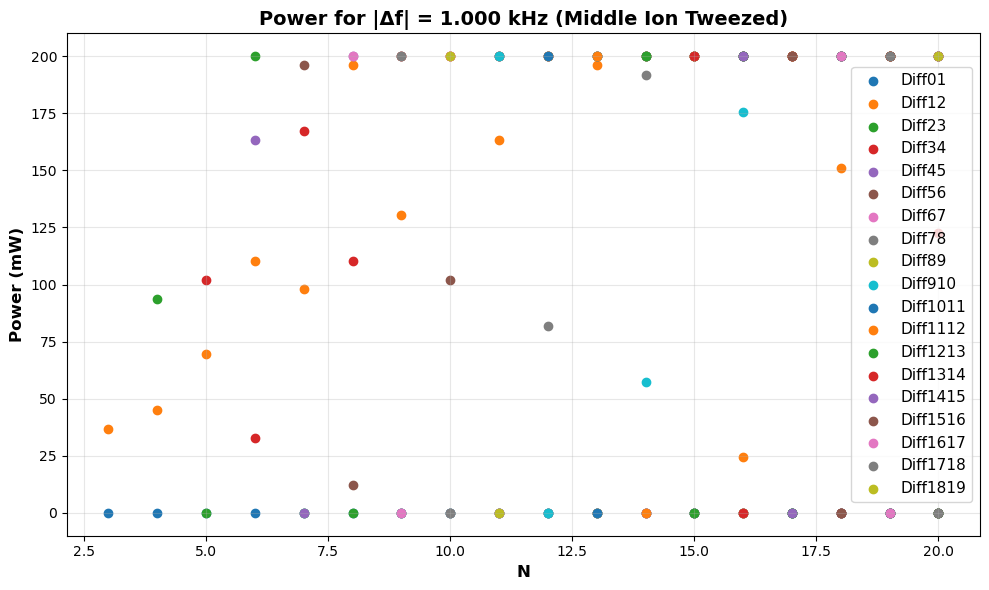

In [7]:
def plot_power_for_target_diff(
    N_values, P_sweep, target_diff_khz, max_tweezed=1, title_suffix="", plot_each_n=False
):
    target_diff_hz = target_diff_khz * 1e3
    max_n = max(N_values)
    power_by_pair = {f"Diff{i}{i+1}": [] for i in range(max_n - 1)}

    for N in N_values:
        if N not in ueq_dict:
            ueq_dict[N] = ion_spacing(N, f_rf_a * 2 * pi)[0]

        all_modes = []
        for P in P_sweep:
            result_df = tweezer_combos_full_radial_middle_only(
                omega_tweezer,
                linewidths,
                omega_res,
                m,
                mode_calc_r,
                [N],
                f_rf_r,
                ueq_dict,
                P,
                w0,
                max_tweezed=max_tweezed,
                qubit_lambda=729e-9
            )
            all_modes.append(result_df)

        mode_freqs = {i: [] for i in range(N)}
        for result in all_modes:
            for mode_idx in range(N):
                freq = result[f"Mode{mode_idx}_freq"].values[0]
                mode_freqs[mode_idx].append(freq if not np.isnan(freq) else None)

        pair_labels = []
        pair_powers = []
        for i in range(N - 1):
            diffs = []
            for idx in range(len(P_sweep)):
                f1 = mode_freqs[i][idx]
                f2 = mode_freqs[i + 1][idx]
                if f1 is None or f2 is None:
                    diffs.append(None)
                else:
                    diffs.append(abs(f2 - f1))

            valid = [(j, d) for j, d in enumerate(diffs) if d is not None]
            if not valid:
                power_by_pair[f"Diff{i}{i+1}"].append(None)
                pair_labels.append(f"Diff{i}{i+1}")
                pair_powers.append(None)
                continue

            j_best, _ = min(valid, key=lambda item: abs(item[1] - target_diff_hz))
            power_mw = P_sweep[j_best] * 1e3
            power_by_pair[f"Diff{i}{i+1}"].append(power_mw)
            pair_labels.append(f"Diff{i}{i+1}")
            pair_powers.append(power_mw)

        for i in range(N - 1, max_n - 1):
            power_by_pair[f"Diff{i}{i+1}"].append(None)

        if plot_each_n:
            valid_pairs = [(lbl, pwr) for lbl, pwr in zip(pair_labels, pair_powers) if pwr is not None]
            if valid_pairs:
                labels, powers = zip(*valid_pairs)
                plt.figure(figsize=(10, 6))
                plt.scatter(powers, labels, marker='o')
                plt.xlabel('Power (mW)', fontsize=12, fontweight='bold')
                plt.ylabel('Adjacent Mode Pair', fontsize=12, fontweight='bold')
                title = f'Power for |Δf| = {target_diff_khz:.3f} kHz (N={N})'
                if title_suffix:
                    title = f"{title} {title_suffix}"
                plt.title(title, fontsize=14, fontweight='bold')
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

    plt.figure(figsize=(10, 6))
    for i in range(max_n - 1):
        key = f"Diff{i}{i+1}"
        valid_powers = [p for p in power_by_pair[key] if p is not None]
        valid_Ns = [N_values[j] for j, p in enumerate(power_by_pair[key]) if p is not None]
        if valid_powers:
            plt.scatter(valid_Ns, valid_powers, marker='o', label=key)

    plt.xlabel('N', fontsize=12, fontweight='bold')
    plt.ylabel('Power (mW)', fontsize=12, fontweight='bold')
    title = f'Power for |Δf| = {target_diff_khz:.3f} kHz'
    if title_suffix:
        title = f"{title} {title_suffix}"
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example:
N_list = np.arange(3, 21)  # N from 3 to 20
plot_power_for_target_diff(N_list, P_sweep, target_diff_khz=1.0, max_tweezed=2, title_suffix='(Middle Ion Tweezed)')